In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Exploração inicial do df

In [3]:
df = pd.read_csv("../data/titanic.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [4]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
df["Embarked"].unique()

<StringArray>
['S', 'C', 'Q', nan]
Length: 4, dtype: str

In [7]:
df["Pclass"].unique()

array([3, 1, 2])

Pela breve análise inicial, foi possível observar a forma geral desse dataset do Titanic.
Existem dados de 891 passageiros, divididos em 12 categorias (colunas): 

- ID do passageiro (int);
- Se o passageiro sobreviveu ou não ao desastre (bin);
- Classe à qual o passageiro embarcou. Sendo elas: 1ª,2ª ou 3ª classe (int));
- Nome (str);
- Sexo (str);
- Idade (float);
- Quantia de irmãos(ãs) e/ou conjuges do passageiro à bordo (int);
- Quantia de filhos e/ou parentes do passageiro à bordo (int);
- Identificador do bilhete do passageiro (str);
- Valor do ingresso de entrada, associado à classe do passageiro (float);
- Cabine em que o passageiro se hospedou (str);
- Onde o passageiro embarcou. À saber: Southampton (Inglaterra), Cherbourg (França) ou Queenstown (Irlanda) (str).

## Investigação dos dados

In [8]:
df["Pclass"].value_counts()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

In [9]:
df["Pclass"].value_counts(normalize=True) * 100

Pclass
3    55.106622
1    24.242424
2    20.650954
Name: proportion, dtype: float64

Aqui, nota-se que a maior parte dos passageiros (~55%) está na 3ª classe e o restante dividido entre a 1ª e a 2ª 

In [17]:
df["Family size"] = df["SibSp"] + df["Parch"] + 1
df["Family size"].describe()

count    891.000000
mean       1.904602
std        1.613459
min        1.000000
25%        1.000000
50%        1.000000
75%        2.000000
max       11.000000
Name: Family size, dtype: float64

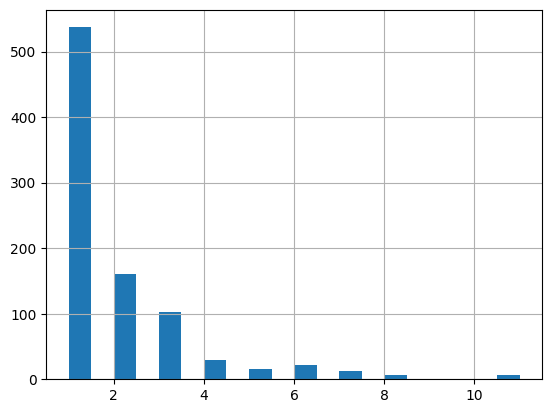

In [ ]:
df["Family size"].hist(bins=20)
plt.show()

In [11]:
df["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

Observamos que 549 dos 891 passageiros do Titanic (cerca de 60%) não sobreviveu ao desastre. 342 sobreviveram e há 28 passageiros com status desconhecido.

In [12]:
df["Sex"].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

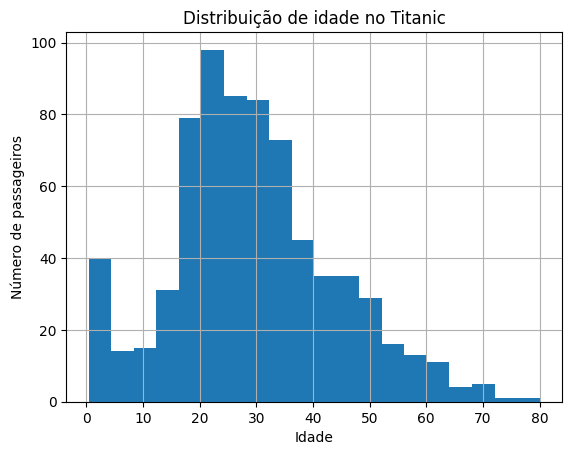

In [13]:
df["Age"].hist(bins=20)
plt.xlabel("Idade")
plt.ylabel("Número de passageiros")
plt.title("Distribuição de idade no Titanic")
plt.show()

Qualitativamente, observa-se que há uma maior concentração de pessoas numa faixa etária de ~20 a ~35 anos de idade, sendo a maioria composta pelo sexo masculino. Há também uma quantia relativamente significativa de bebês à bordo.

In [14]:
grupos_idade = [0,1,5,10,20,30,40,50,60,70,80]
df["Age group"] = pd.cut(df["Age"], bins = grupos_idade)
mortos = df[df["Survived"] == 0]
agrupamento = mortos.groupby(["Age group", "Sex"]).size()
tabela_mortalidade = agrupamento.unstack()
tabela_mortalidade

Sex,female,male
Age group,,
"(0, 1]",NaN,2.0
"(1, 5]",5.0,6.0
"(5, 10]",7.0,6.0
"(10, 20]",12.0,59.0
"(20, 30]",20.0,126.0
"(30, 40]",9.0,77.0
"(40, 50]",10.0,43.0
"(50, 60]",1.0,24.0
"(60, 70]",NaN,13.0


Text(0.5, 1.0, 'Mortalidade por idade e sexo no Titanic')

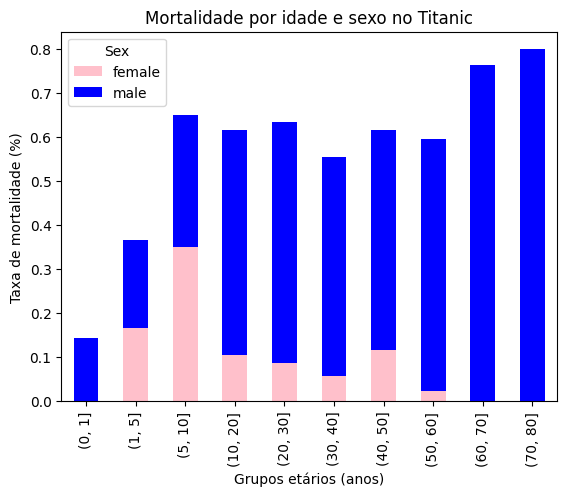

In [15]:
total_por_idade = df.groupby("Age group").size()
taxa_mortalidade = tabela_mortalidade.div(total_por_idade, axis=0)
taxa_mortalidade.plot(kind="bar", stacked=True, color=["pink", "blue"])
plt.xlabel("Grupos etários (anos)")
plt.ylabel("Taxa de mortalidade (%)")
plt.title("Mortalidade por idade e sexo no Titanic")

Com base neste último gráfico, é possível notar um padrão: a taxa de mortalidade masculina foi muito maior do que a feminina, para todas as idades. Isso indica que, provavelmente, houve um protocolo durante o desastre de priorizar em salvar as mulheres.

Além disso, também é possível observar que a taxa de mortalidade dos bebês foi proporcionalmente a mais baixa em relação à outros grupos etários - sinalizando para uma priorização em salvá-los, também.